In [7]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os

current_dir = os.getcwd()

project_root = os.path.abspath(os.path.join(current_dir, '..'))
prefix = '../'

# On ajoute la racine du projet au PATH de Python pour qu'il trouve 'config.py'
if project_root not in sys.path:
    sys.path.append(project_root)
# ---------------------------------------------
from config import params
from utils.Functions import split_dataset

# 1. Charger les données brutes (avec le bon préfixe)
df = pd.read_csv(prefix + params['data_dir'] + params['data_name'])

# 2. Charger le modèle entraîné (Changez 'sgd' par 'logistic' ou 'mlp')
model_name = 'sgd'
model_path = f'{prefix}model_output/{model_name}/{model_name}.pkl'
model = joblib.load(model_path)

# 3. Préparer les données
y = df[params['colonne_cible']]
X = df.drop(columns=[params['colonne_cible']])
X_train, X_test, y_train, y_test = split_dataset(X, y)
X, y = model.prepare(X_train, y_train)
print(f"Modèle {model_name} et données chargés avec succès !")
print(f"Taille du jeu de test : {X_test.shape[0]} lignes")

Modèle sgd et données chargés avec succès !
Taille du jeu de test : 28439 lignes


💡 Interprétation : Les barres vers la droite (positives) poussent le modèle à dire "Il va pleuvoir". Les barres vers la gauche (négatives) le poussent à dire "Il fera beau". La taille de la barre donne son importance absolue.

In [9]:
print(len(colonnes))
print(len(coefficients))
print(X_train.shape)
print(model.coef_.shape)

19
27
(113754, 27)
(1, 27)


In [ ]:
# Récupération des colonnes et des coefficients
colonnes = model.feature_names_
coefficients = model.coef_[0]

# Création d'un tableau trié par importance absolue
df_importance = pd.DataFrame({
    'Variable': colonnes,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)

# Affichage du graphique
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importance, x='Coefficient', y='Variable', palette='vlag')
plt.title("Importance des variables météo dans la décision du modèle")
plt.axvline(0, color='black', linestyle='--')
plt.show()


ValueError: All arrays must be of the same length

On va construire un tableau qui filtre uniquement les moments où le modèle s'est planté, pour essayer de comprendre pourquoi.

💡 Interprétation : Comparez ce .describe() avec la moyenne globale de votre jeu de données. Y a-t-il une anomalie ? Par exemple, le modèle rate-t-il systématiquement les pluies fines quand la pression est haute ?

In [ ]:
# 1. Obtenir les prédictions
y_pred = model.predict(X_test)

# 2. Reconstruire un tableau lisible
df_test = X_test.copy()
df_test['Vraie_Pluie'] = y_test
df_test['Prediction'] = y_pred

# 3. Filtrer les Faux Négatifs (Il a plu en vrai, mais le modèle a dit non)
faux_negatifs = df_test[(df_test['Vraie_Pluie'] == 1) & (df_test['Prediction'] == 0)]

print(f"Nombre d'erreurs (Faux Négatifs) : {len(faux_negatifs)} jours.")

# Regardons les caractéristiques moyennes de ces jours où le modèle s'est trompé
display(faux_negatifs.describe())


Nombre d'erreurs (Faux Négatifs) : 3030 jours.


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Vraie_Pluie,Prediction
count,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.0,3030.0
mean,0.201617,0.030944,0.001313,-0.120849,-0.238262,0.128454,-0.049134,0.039531,0.117661,0.161826,-0.404630,-0.403438,0.252602,0.318942,0.143973,0.027351,1.0,0.0
std,1.066282,1.051310,0.595626,0.820005,0.789214,0.927069,0.845100,0.866975,0.916809,0.761772,0.875545,0.900098,0.845071,0.759984,1.079422,1.058913,0.0,0.0
min,-2.154570,-2.126328,-0.864541,-1.983265,-2.136293,-2.432968,-1.575823,-2.128654,-3.303347,-2.194720,-4.123765,-3.468116,-2.662652,-1.892334,-2.636287,-2.124593,1.0,0.0
25%,-0.560652,-0.748848,-0.279684,-0.702776,-0.758284,-0.503962,-0.561070,-0.643522,-0.415859,-0.266645,-1.002967,-1.075313,-0.298292,-0.203410,-0.639288,-0.733555,1.0,0.0
50%,-0.013720,-0.242835,-0.279684,-0.253704,-0.294425,-0.004748,-0.110068,0.041924,0.214138,0.263576,-0.381990,-0.347068,0.430338,0.427654,-0.116996,-0.231633,1.0,0.0
75%,0.830119,0.906236,-0.018669,0.339517,0.303931,0.757312,0.566434,0.613128,0.739136,0.697392,0.174692,0.208282,1.026432,1.063283,0.835419,0.829571,1.0,0.0
max,2.814704,2.990026,6.981268,6.898366,2.513306,4.466939,3.385192,5.068526,1.631633,2.239852,2.633056,2.714531,1.917546,1.722631,2.863142,3.081046,1.0,0.0


On va demander à Scikit-Learn de tracer la façon dont le modèle réagit quand on fait varier artificiellement l'Humidité ou la Pression.

💡 Interprétation : L'axe vertical est la "probabilité de pluie" prédite par le modèle. L'axe horizontal est la variable météo. Vous devriez voir, par exemple, la courbe monter en flèche lorsque l'humidité dépasse les 60-70%.

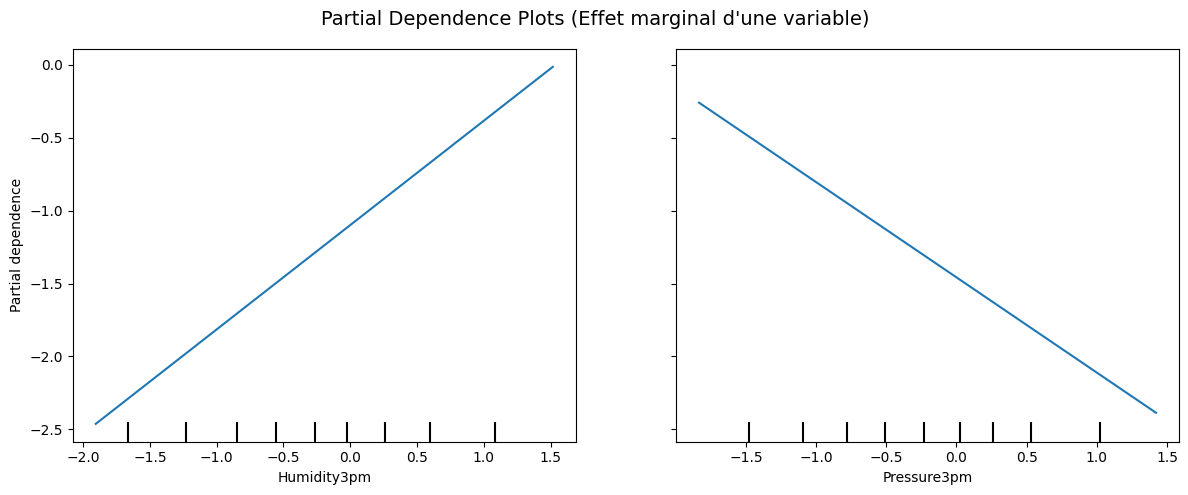

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

# Choisissez 2 ou 3 variables que vous trouvez importantes (vu dans la Cellule 2)
features_a_tester = ['Humidity3pm', 'Pressure3pm']

fig, ax = plt.subplots(figsize=(12, 5))
PartialDependenceDisplay.from_estimator(
    model, 
    X_test, 
    features_a_tester, 
    ax=ax,
    grid_resolution=50 # Qualité de la courbe
)

fig.suptitle("Partial Dependence Plots (Effet marginal d'une variable)", fontsize=14)
plt.tight_layout()
plt.show()
